In [4]:
import pandas as pd
from pathlib import Path
import os
from helpers.load import *
from helpers.select_scenario import *

scenario_folder_air = Path(os.path.abspath('')) / 'logs' / 'unified' / 'air'
scenario_folder_freshwater = Path(os.path.abspath('')) / 'logs' / 'unified' / 'freshwater'

def load_scenario_aggregate_df(scenario_folder, loader_function):
    node_pos_df = pd.DataFrame()
    for config_folder in sorted([folder for folder in scenario_folder.iterdir() if folder.is_dir()]):
        temp_df = loader_function(config_folder)
        temp_df['Config'] = config_folder.name
        node_pos_df = pd.concat([node_pos_df, temp_df])
    
    return node_pos_df.reset_index(drop=True)

# Load positions for both scenarios
node_pos_df_air = load_scenario_aggregate_df(scenario_folder_air, load_node_pos_df)
node_pos_df_freshwater = load_scenario_aggregate_df(scenario_folder_freshwater, load_node_pos_df)

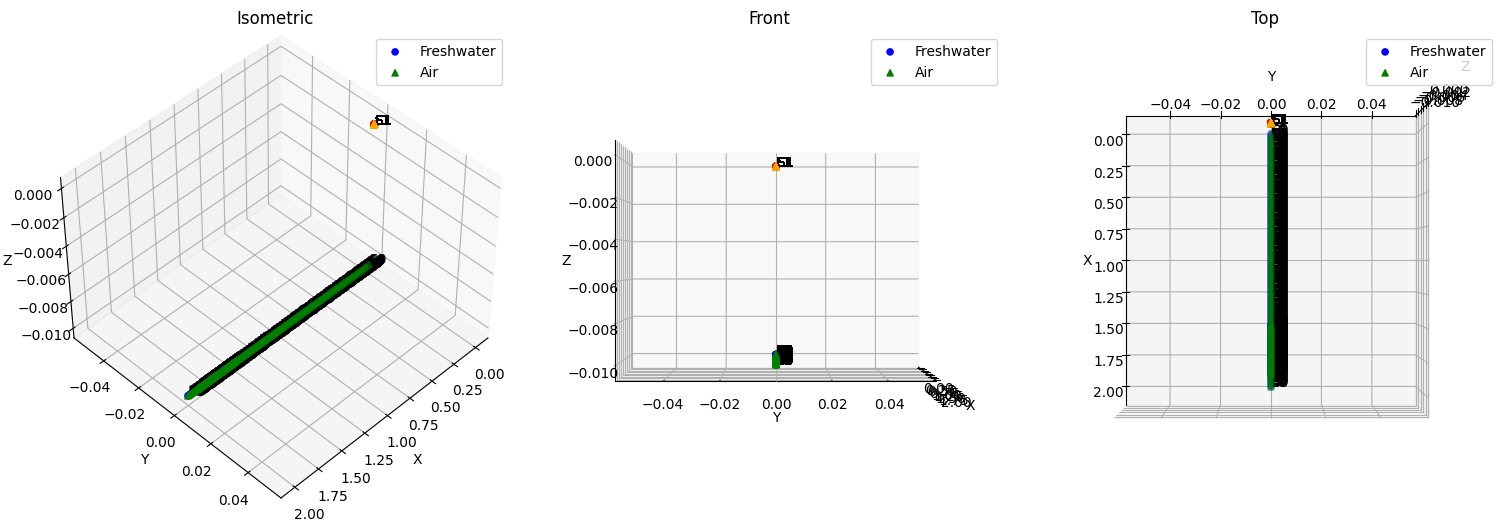

In [5]:
# Plot a 3D graph using the x, y, z coordinates. Color the nodes based on type.
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Map 'Type' to colors for each scenario
color_map_freshwater = {'AP': 'red', 'STA': 'blue'}
color_map_air = {'AP': 'orange', 'STA': 'green'}

colors_freshwater = node_pos_df_freshwater['NodeType'].map(color_map_freshwater)
colors_air = node_pos_df_air['NodeType'].map(color_map_air)

fig = plt.figure(figsize=(15, 5))

# Create 3 subplots showing different viewing angles
angles = [(45, 45), (0, 0), (90, 0)]
titles = ['Isometric', 'Front', 'Top']

for i, (elev, azim) in enumerate(angles, 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    
    # Plot freshwater scenario nodes
    ax.scatter(node_pos_df_freshwater['X'], node_pos_df_freshwater['Y'], node_pos_df_freshwater['Z'], 
              c=colors_freshwater, marker='o', label='Freshwater')
    
    # Plot air scenario nodes
    ax.scatter(node_pos_df_air['X'], node_pos_df_air['Y'], node_pos_df_air['Z'], 
              c=colors_air, marker='^', label='Air')
    
    # Add node labels
    for _, row in node_pos_df_freshwater.iterrows():
        ax.text(row['X'], row['Y'], row['Z'], f'L{row["NodeId"]}')
    for _, row in node_pos_df_air.iterrows():
        ax.text(row['X'], row['Y'], row['Z'], f'S{row["NodeId"]}')
    
    # Set viewing angle
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(titles[i-1])
    
    # Set labels and legend
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()

plt.tight_layout()
plt.show()